In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
# To load the dataset and name the columns of the dataset
column_name = ["Variance", "Skewness", "Curtosis", "Entropy", "Target"]
data = pd.read_csv('data_banknote_authentication.txt', header= None)
data.columns = column_name

In [59]:
#To do the task 1
#Display the first 5 samples
print(data.head())

   Variance  Skewness  Curtosis  Entropy  Target
0   3.62160    8.6661   -2.8073 -0.44699       0
1   4.54590    8.1674   -2.4586 -1.46210       0
2   3.86600   -2.6383    1.9242  0.10645       0
3   3.45660    9.5228   -4.0112 -3.59440       0
4   0.32924   -4.4552    4.5718 -0.98880       0


In [60]:
# Determine the dimension
print(data.shape)

(1372, 5)


In [61]:
#Identify the missing values
print(data.isnull().sum())

Variance    0
Skewness    0
Curtosis    0
Entropy     0
Target      0
dtype: int64


In [62]:
#To describe the dataset
data.describe()
data['Target'].value_counts()

,count
Target,
0,762
1,610


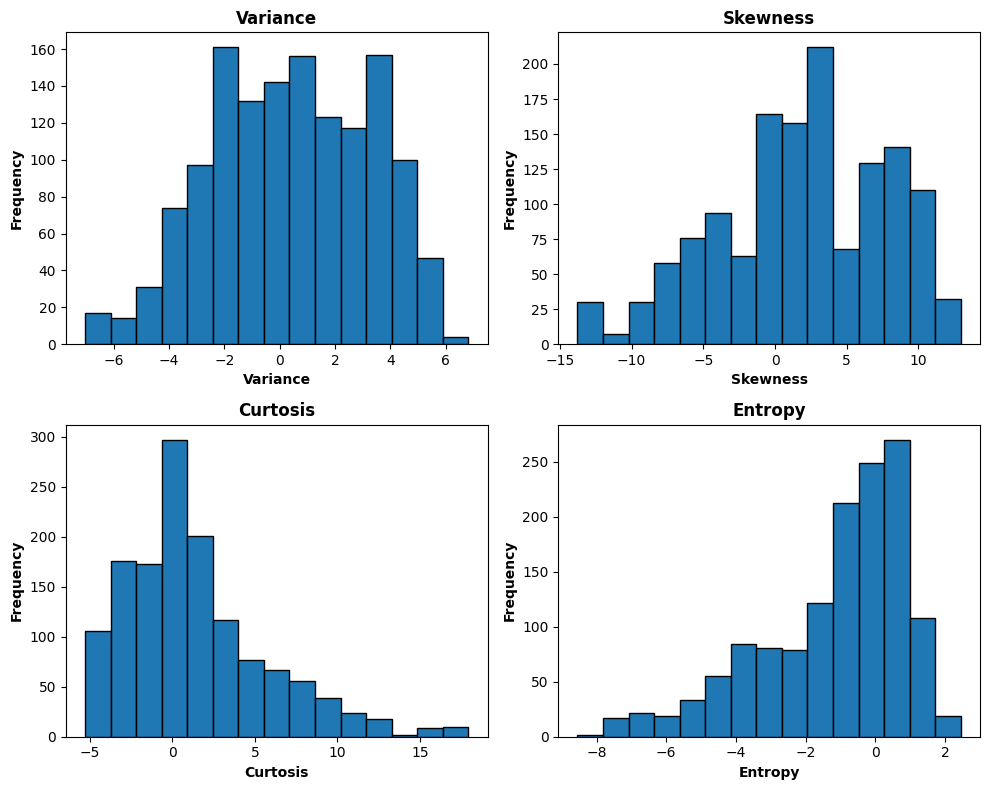

In [63]:
#Ploating the histogram
features = data.columns
fig, axes = plt.subplots(2, 2, figsize=(10,8))
axes = axes.ravel()
for i, col in enumerate(features[:4]):
    axes[i].hist(data[col], bins=15, edgecolor='black')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel(col, fontweight='bold')
    axes[i].set_ylabel("Frequency", fontweight='bold')
plt.tight_layout()
plt.savefig("Histogram.eps", dpi=600, format="eps")
plt.show()

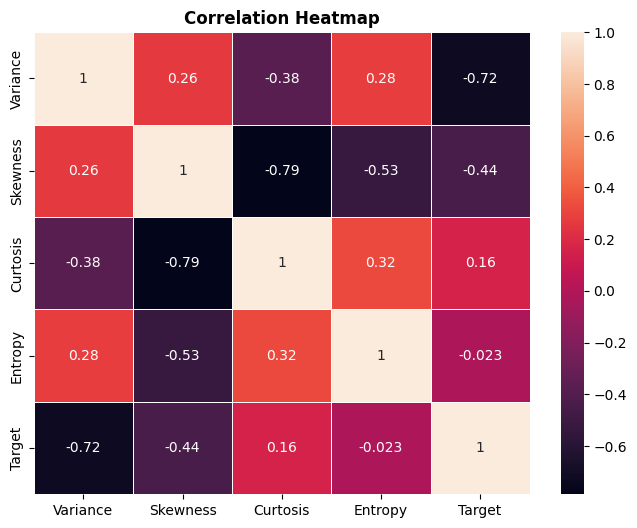

In [64]:
#Ploting correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, linewidths=0.5)
plt.title("Correlation Heatmap", fontweight="bold")
plt.savefig("Heatmap.eps", dpi=600, format="eps")
plt.show()

In [65]:
# #Ploting the Scatter Plot
# plt.scatter( data['Target'],data['Feature1'])
# plt.ylabel('Feature1')
# plt.xlabel('Target')
# plt.show()

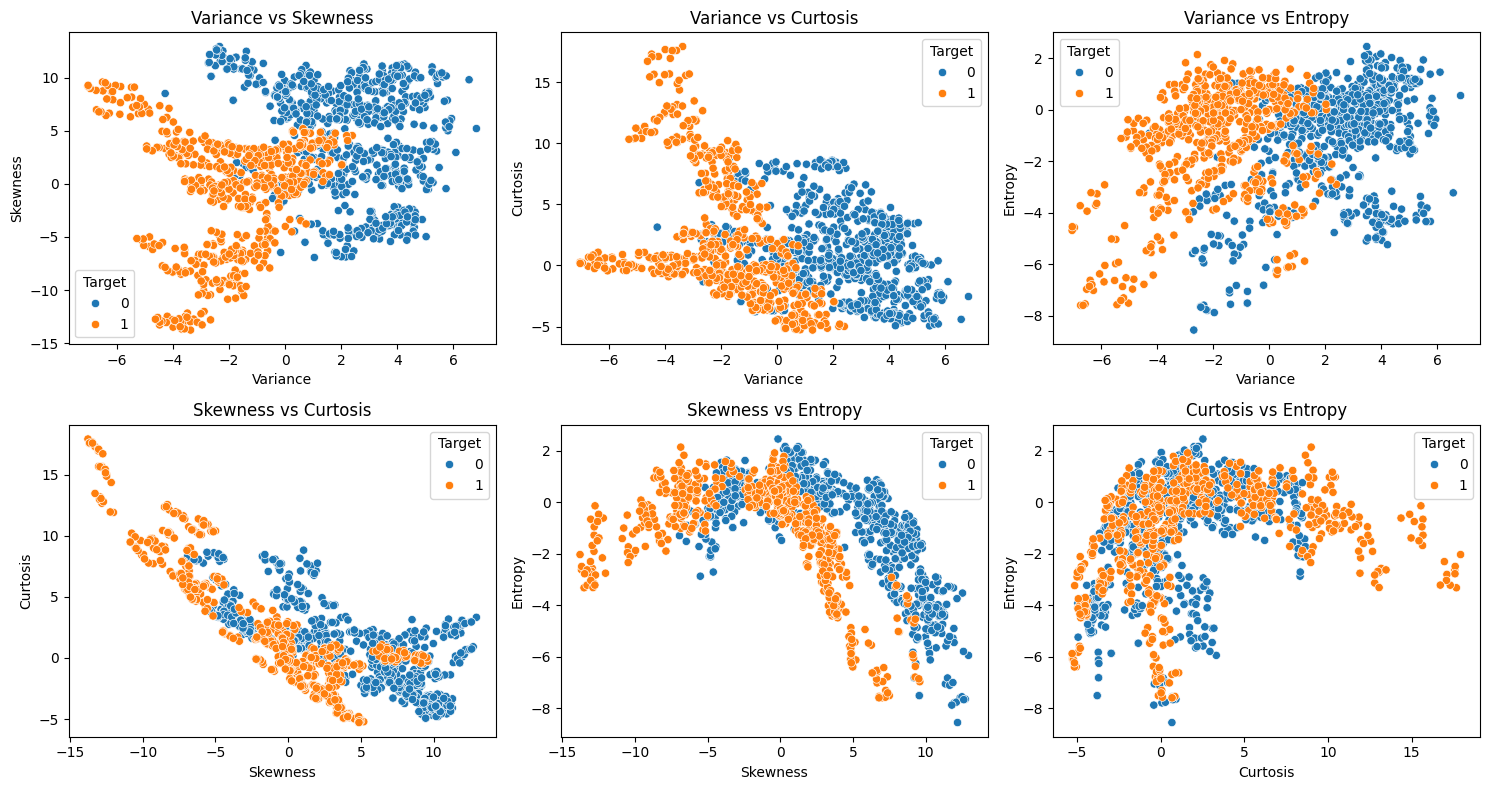

In [85]:
import math
pairs = []
for i in range(len(column_name[:-1])):
    for j in range(i + 1, len(column_name[:-1])):
        pairs.append((i, j))
n_plots = len(pairs)
n_cols = 3
n_rows = math.ceil(n_plots / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()
for idx, (i, j) in enumerate(pairs):
    sns.scatterplot(x=data[column_name[i]],y=data[column_name[j]],hue=data['Target'],ax=axes[idx])
    axes[idx].set_xlabel(column_name[i])
    axes[idx].set_ylabel(column_name[j])
    axes[idx].set_title(f"{column_name[i]} vs {column_name[j]}")
for k in range(idx + 1, len(axes)):
    fig.delaxes(axes[k])
plt.savefig("Scatter.eps", dpi=600, format="eps")
# plt.title("Correlation Heatmap", fontweight="bold")
plt.tight_layout()
plt.show()

In [67]:
#Ploting the Scatter Plot
# dup = []
# fig, axes = plt.subplots(2, 2, figsize = (10, 8))
# axes = axes.ravel()
# for i in range(len(column_name[:-1])):
#     for j in range(len(column_name[:-1])):
#         if i != j and [j, i] not in dup:
#             plt.figure(figsize=(8,6))
#             sns.scatterplot(x=data[column_name[i]],y=data[column_name[j]],hue=data['Target'])
#             plt.xlabel(column_name[i])
#             plt.ylabel(column_name[j])
#             plt.title(f"{column_name[i]} vs {column_name[j]}")
#             dup.append([i, j])
# plt.tight_layout()
# plt.savefig("Scatter_Subplots.eps", dpi=600, format="eps")
# plt.show()

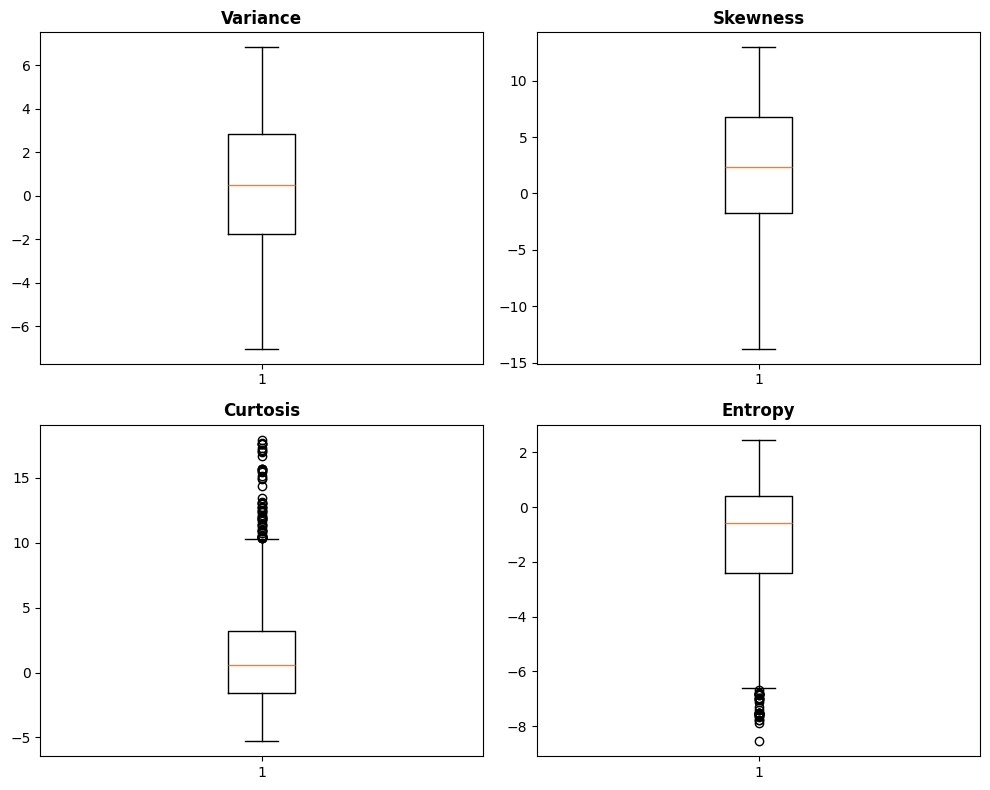

In [68]:
fig, axes = plt.subplots(2,2, figsize=(10,8))
axes = axes.ravel()
for i, col in enumerate(features[:4]):
    axes[i].boxplot(data[col])
    axes[i].set_title(col, fontweight="bold")
plt.tight_layout()
plt.savefig("Boxplots.eps", dpi=600, format="eps")
plt.show()

In [69]:
#Spliting the train and test data
X = data.drop('Target', axis=1)
y = data['Target']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

In [70]:
#To normalise the data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled_train = scaler.fit_transform(X_train)
X_scaled_test = scaler.transform(X_test)

In [71]:
#Activation Function step function
def activation(x):
  if x >= 0:
    return 1
  else:
    return 0

In [72]:
#Forward Propagation
def forward(x1,x2,x3,x4,w1,w2,w3,w4,b):
  z = x1*w1 + x2*w2 + x3*w3 + x4*w4 + b
  return activation(z)

In [73]:
#Weight Update Rule or perceptron learning rule
def weighupdate(learning_rate,w1,w2,w3,w4,b,X_train,y_train):
  misclass = []
  for i in range(len(X_train)):
    x1 = X_train[i][0]
    x2 = X_train[i][1]
    x3 = X_train[i][2]
    x4 = X_train[i][3]
    y = y_train[i]
    ypred = forward(x1,x2,x3,x4,w1,w2,w3,w4,b)
    if y - ypred == 0:
      continue
    else:
      misclass.append(i)
      w1 = w1 + learning_rate*(y-ypred)*x1
      w2 = w2 + learning_rate*(y-ypred)*x2
      w3 = w3 + learning_rate*(y-ypred)*x3
      w4 = w4 + learning_rate*(y-ypred)*x4
      b = b + learning_rate*(y-ypred)
  fiweigh = [w1,w2,w3,w4]
  return fiweigh,b,misclass

In [74]:
#To implement the epoch to train the perceptron
def epochcount(learning_rate,w1,w2,w3,w4,b,X_train,y_train,epoch):
  limit = 0.0001
  misclass_limit = 1372
  test_param = []
  epoch_list = []
  misclass_list_graph = []
  bias_list_graph = []
  weight1_list_graph = []
  weight2_list_graph = []
  weight3_list_graph = []
  weight4_list_graph = []
  for i in range(epoch):
    old_w1,old_w2,old_w3,old_w4 = w1,w2,w3,w4
    weigh = []
    misclass_epoch = []
    weigh,b,misclass_epoch = weighupdate(learning_rate,w1,w2,w3,w4,b,X_train,y_train)
    if len(misclass_epoch) < misclass_limit:
      misclass_limit = len(misclass_epoch)
      wf1 = weigh[0]
      wf2 = weigh[1]
      wf3 = weigh[2]
      wf4 = weigh[3]
      bf = b
    print(weigh)
    print("Epoch",i)
    print('Bias = ',b)
    print('Number of mis classified points = ',len(misclass_epoch))
    w1 = weigh[0]
    w2 = weigh[1]
    w3 = weigh[2]
    w4 = weigh[3]
    print('Weight 1 = ',w1,'Weight 2 = ',w2,'Weight 3 = ',w3,'Weight 4 = ',w4)
    weight_change = (abs(w1-old_w1) + abs(w2-old_w2) + abs(w3-old_w3) + abs(w4-old_w4))
    misclass_list_graph.append(len(misclass_epoch))
    bias_list_graph.append(b)
    weight1_list_graph.append(w1)
    weight2_list_graph.append(w2)
    weight3_list_graph.append(w3)
    weight4_list_graph.append(w4)
    epoch_list.append(i+1)
    print()
    if len(misclass_epoch) == 0:
      print("Model converged")
      test_param.append([wf1,wf2,wf3,wf4,bf])
      return test_param
    if weight_change < limit:
        print("Model converged: weights stabilized.")
        test_param.append([wf1,wf2,wf3,wf4,bf])
        return test_param
  test_param.append([wf1,wf2,wf3,wf4,bf,misclass_limit])
  fig, axes = plt.subplots(2, 2, figsize=(14, 10))
  axes = axes.ravel()
  plt.figure(figsize=(8,6))
  plt.plot(epoch_list, misclass_list_graph,marker='o',linewidth=2,markersize=6)
  plt.xlabel('Epoch', fontsize=12, fontweight='bold')
  plt.ylabel('Misclassified Points', fontsize=12, fontweight='bold')
  plt.title('Epoch vs Misclassified Points',fontsize=14,fontweight='bold')
  plt.xticks(fontsize=10)
  plt.yticks(fontsize=10)
  plt.grid(True)
  plt.tight_layout()
  plt.savefig("Misclassified_vs_Epoch.eps",dpi=600,format='eps',bbox_inches='tight')
  plt.show()


# # ------------------ Bias ------------------
  plt.figure(figsize=(8,6))
  plt.plot(epoch_list, bias_list_graph,marker='o',linewidth=2,markersize=6)
  plt.xlabel('Epoch', fontsize=12, fontweight='bold')
  plt.ylabel('Bias', fontsize=12, fontweight='bold')
  plt.title('Epoch vs Bias',fontsize=14,fontweight='bold')
  plt.xticks(fontsize=10)
  plt.yticks(fontsize=10)
  plt.grid(True)
  plt.tight_layout()
  plt.savefig("Bias_vs_Epoch.eps",dpi=600,format='eps',bbox_inches='tight')
  plt.show()

 # ------------------ Weights and Bias ------------------
  plt.figure(figsize=(10,6))
  plt.plot(epoch_list, weight1_list_graph,label='W1',linewidth=2)
  plt.plot(epoch_list, weight2_list_graph,label='W2',linewidth=2)
  plt.plot(epoch_list, weight3_list_graph,label='W3',linewidth=2)
  plt.plot(epoch_list, weight4_list_graph,label='W4',linewidth=2)
  # plt.plot(epoch_list, bias_list_graph,label='Bias',linewidth=2)
  plt.xlabel('Epoch', fontsize=12, fontweight='bold')
  plt.ylabel('Value', fontsize=12, fontweight='bold')
  plt.title('Weights and Bias vs Epoch',fontsize=14,fontweight='bold')
  plt.xticks(fontsize=10)
  plt.yticks(fontsize=10)
  plt.legend(fontsize=10)
  plt.grid(True)
  plt.tight_layout()
  plt.savefig("Weights_and_Bias_vs_Epoch.eps",dpi=600,format='eps',bbox_inches='tight')
  plt.show()
  return test_param

[np.float64(-0.07529561336708274), np.float64(-0.054779851223774254), np.float64(-0.0656407120709656), np.float64(0.0190777930453503)]
Epoch 0
Bias =  0.08
Number of mis classified points =  192
Weight 1 =  -0.07529561336708274 Weight 2 =  -0.054779851223774254 Weight 3 =  -0.0656407120709656 Weight 4 =  0.0190777930453503

[np.float64(-0.08282198999055301), np.float64(-0.07188328924178757), np.float64(-0.08476376985342005), np.float64(0.01699276884915991)]
Epoch 1
Bias =  0.09999999999999999
Number of mis classified points =  78
Weight 1 =  -0.08282198999055301 Weight 2 =  -0.07188328924178757 Weight 3 =  -0.08476376985342005 Weight 4 =  0.01699276884915991

[np.float64(-0.0891620443646381), np.float64(-0.07808857723379496), np.float64(-0.09473968053405335), np.float64(0.004676220901389985)]
Epoch 2
Bias =  0.10999999999999999
Number of mis classified points =  43
Weight 1 =  -0.0891620443646381 Weight 2 =  -0.07808857723379496 Weight 3 =  -0.09473968053405335 Weight 4 =  0.0046762209

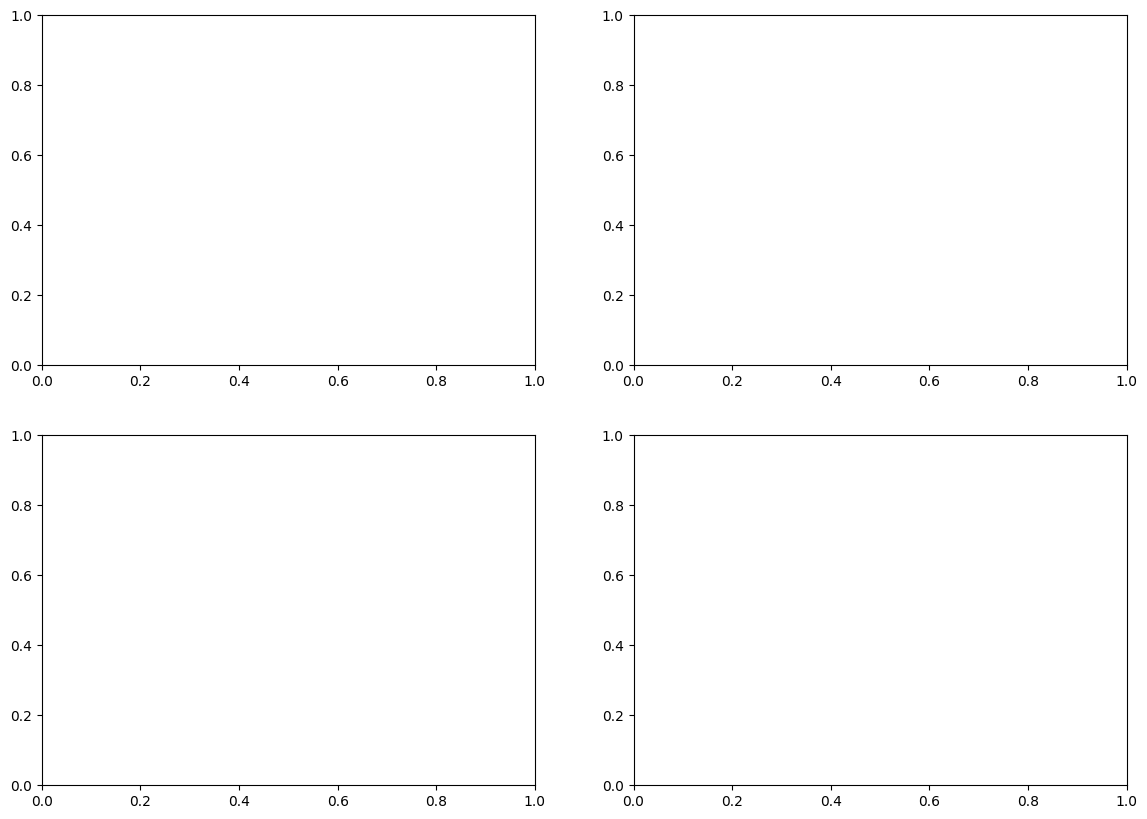

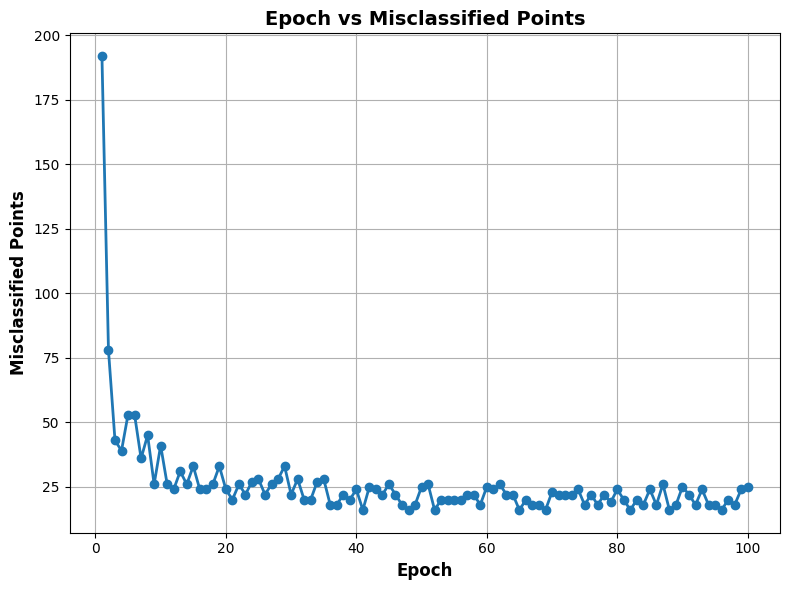

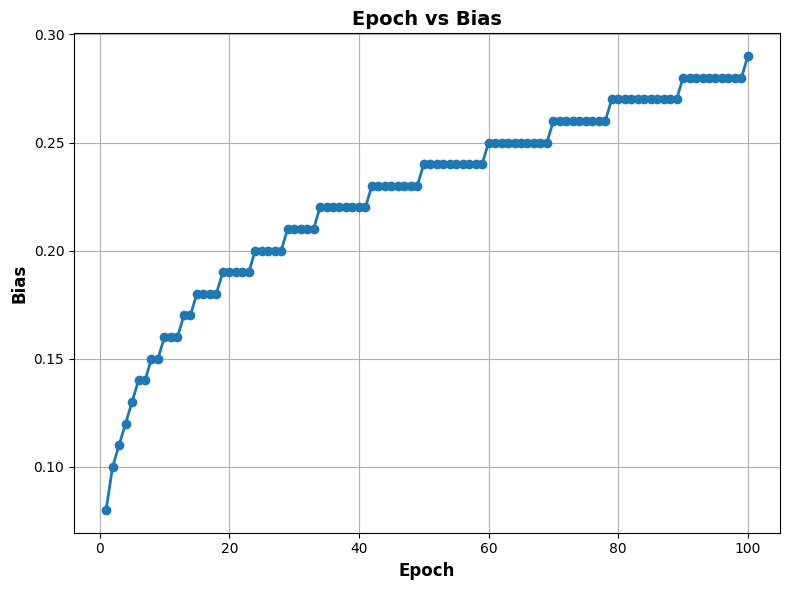

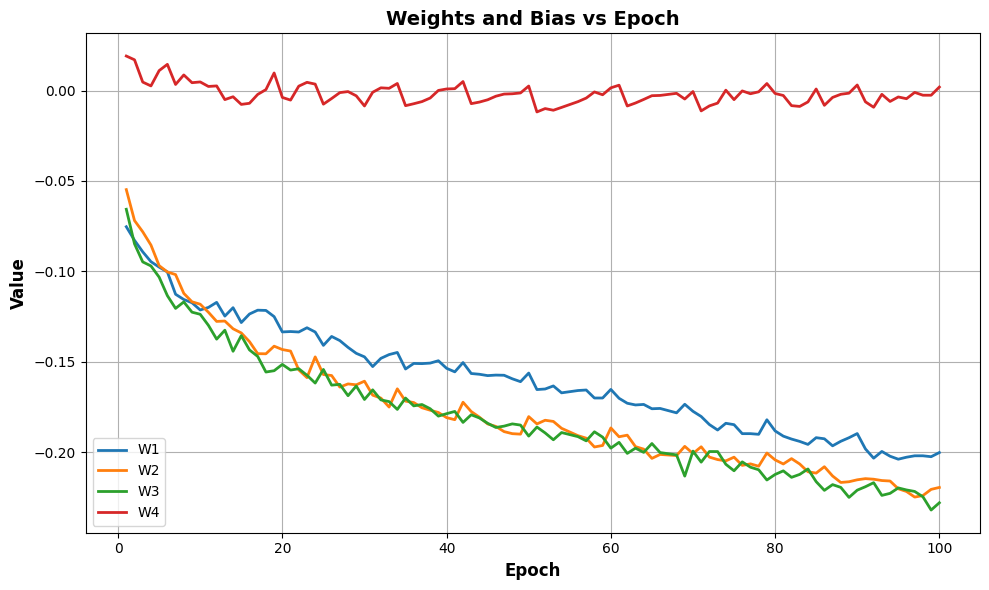

[np.float64(-0.15552388212217685), np.float64(-0.18197352673743716), np.float64(-0.1774085317417544), np.float64(0.0010315975101792031), np.float64(0.22000000000000006), 16]


In [75]:
#Initilizing the weights and bias
w1=w2=w3=w4=b = 0
epoch = 100
learning_rate = 0.01
ans =[]
ans = epochcount(learning_rate,w1,w2,w3,w4,b,X_scaled_train,y_train,epoch)
print(ans[0])

In [76]:
def learning_diff(w1,w2,w3,w4,b,X_scaled_train,y_train,epoch):

    learning_rate = [0.001,0.01,1]
    learningrate_compare = []
    misclassified_points = []

    print("\n{:^20} {:^25}".format("Learning Rate","Misclassified Points"))
    for lr in learning_rate:
        result = epochcount(lr,w1,w2,w3,w4,b,X_scaled_train,y_train,epoch)
        learningrate_compare.append(result)
        misclass = result[0][-1]
        misclassified_points.append(misclass)
        print("{:^20} {:^25}".format(lr, misclass))
    plt.figure(figsize=(8,6))
    plt.plot(learning_rate,misclassified_points,marker='o',linewidth=2,markersize=8)
    plt.xlabel('Learning Rate',fontsize=12,fontweight='bold')
    plt.ylabel('Misclassified Points',fontsize=12,fontweight='bold')
    plt.title('Learning Rate vs Misclassified Points',fontsize=14,fontweight='bold')

    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("LearningRate_vs_Misclassified.eps",dpi=600,format='eps',bbox_inches='tight')
    plt.show()

    return learning_rate, learningrate_compare


   Learning Rate       Misclassified Points   
[np.float64(-0.007529561336708277), np.float64(-0.005477985122377424), np.float64(-0.006564071207096559), np.float64(0.0019077793045350314)]
Epoch 0
Bias =  0.008
Number of mis classified points =  192
Weight 1 =  -0.007529561336708277 Weight 2 =  -0.005477985122377424 Weight 3 =  -0.006564071207096559 Weight 4 =  0.0019077793045350314

[np.float64(-0.0082821989990553), np.float64(-0.007188328924178752), np.float64(-0.008476376985341998), np.float64(0.0016992768849159942)]
Epoch 1
Bias =  0.010000000000000002
Number of mis classified points =  78
Weight 1 =  -0.0082821989990553 Weight 2 =  -0.007188328924178752 Weight 3 =  -0.008476376985341998 Weight 4 =  0.0016992768849159942

[np.float64(-0.0089162044364638), np.float64(-0.007808857723379493), np.float64(-0.009473968053405321), np.float64(0.0004676220901390015)]
Epoch 2
Bias =  0.011000000000000003
Number of mis classified points =  43
Weight 1 =  -0.0089162044364638 Weight 2 =  -0.007

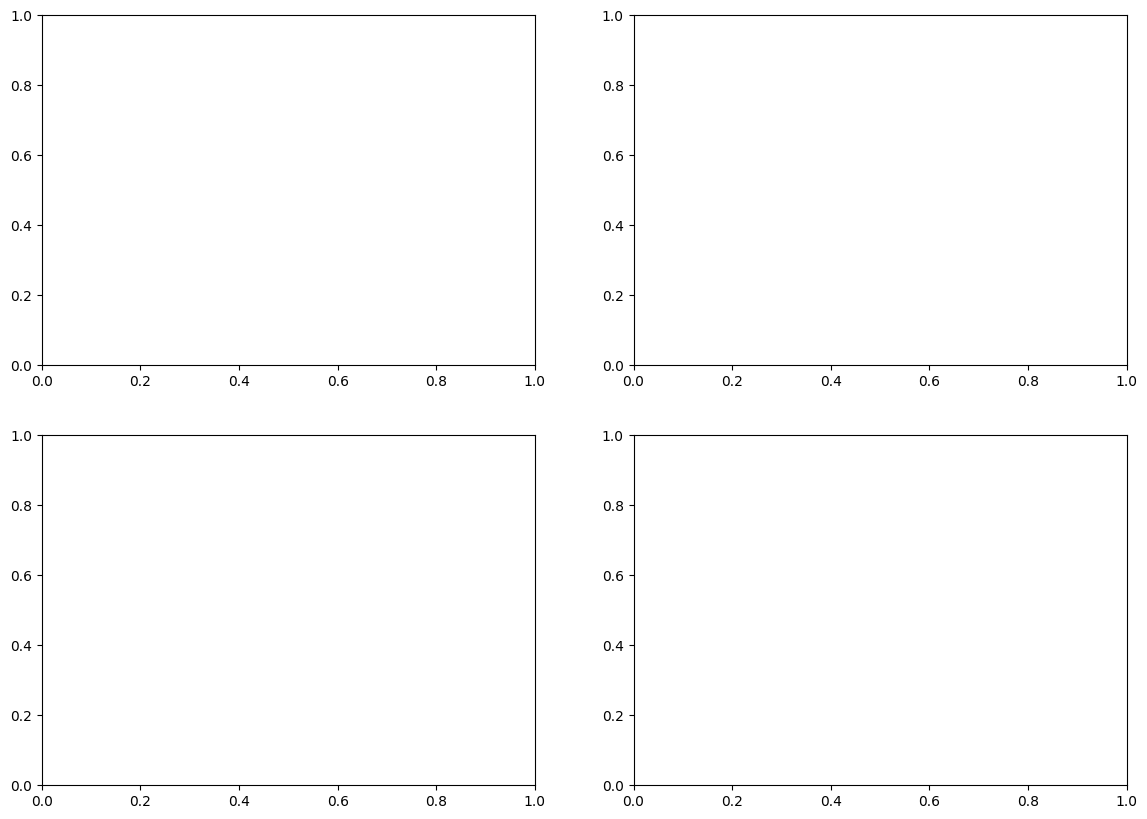

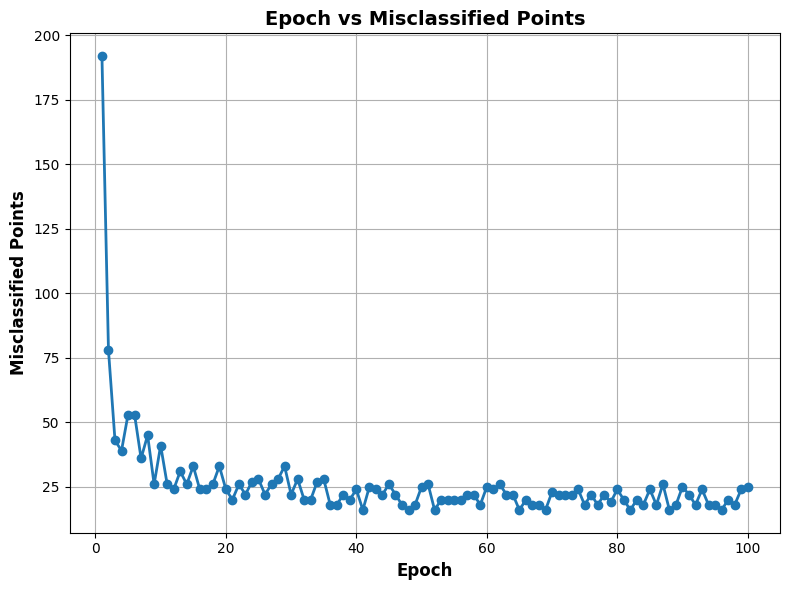

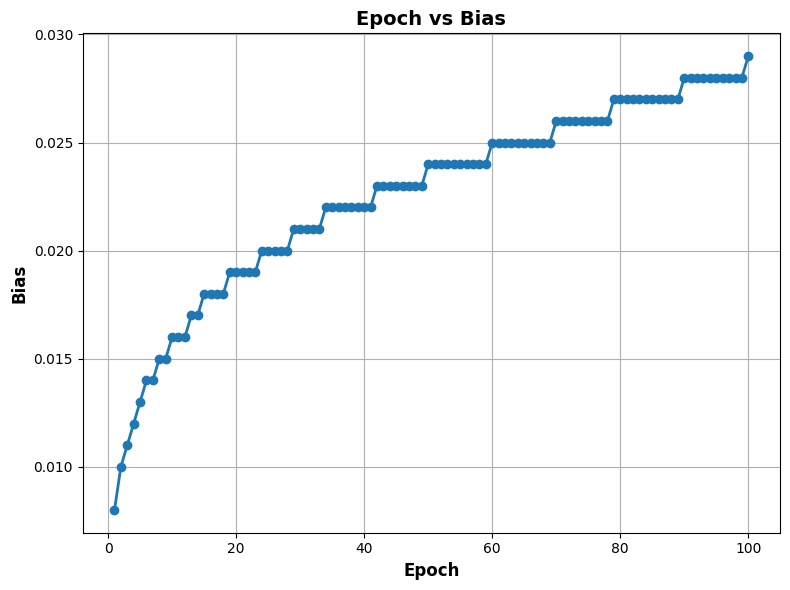

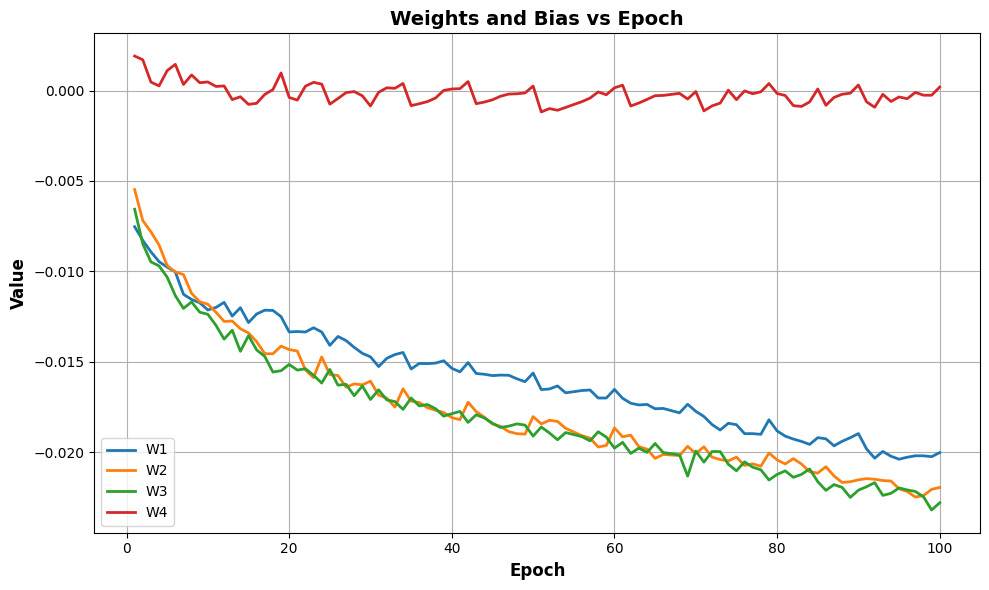

       0.001                    16            
[np.float64(-0.07529561336708274), np.float64(-0.054779851223774254), np.float64(-0.0656407120709656), np.float64(0.0190777930453503)]
Epoch 0
Bias =  0.08
Number of mis classified points =  192
Weight 1 =  -0.07529561336708274 Weight 2 =  -0.054779851223774254 Weight 3 =  -0.0656407120709656 Weight 4 =  0.0190777930453503

[np.float64(-0.08282198999055301), np.float64(-0.07188328924178757), np.float64(-0.08476376985342005), np.float64(0.01699276884915991)]
Epoch 1
Bias =  0.09999999999999999
Number of mis classified points =  78
Weight 1 =  -0.08282198999055301 Weight 2 =  -0.07188328924178757 Weight 3 =  -0.08476376985342005 Weight 4 =  0.01699276884915991

[np.float64(-0.0891620443646381), np.float64(-0.07808857723379496), np.float64(-0.09473968053405335), np.float64(0.004676220901389985)]
Epoch 2
Bias =  0.10999999999999999
Number of mis classified points =  43
Weight 1 =  -0.0891620443646381 Weight 2 =  -0.07808857723379496 Weight 3 =

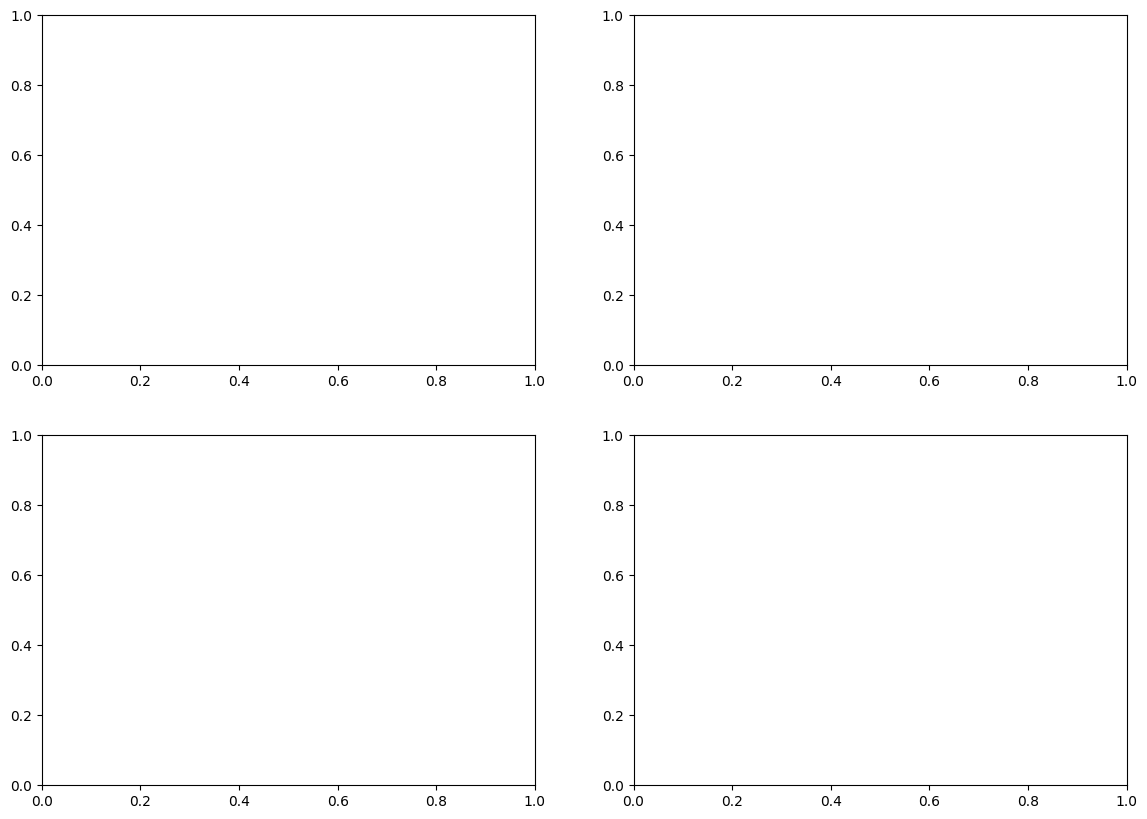

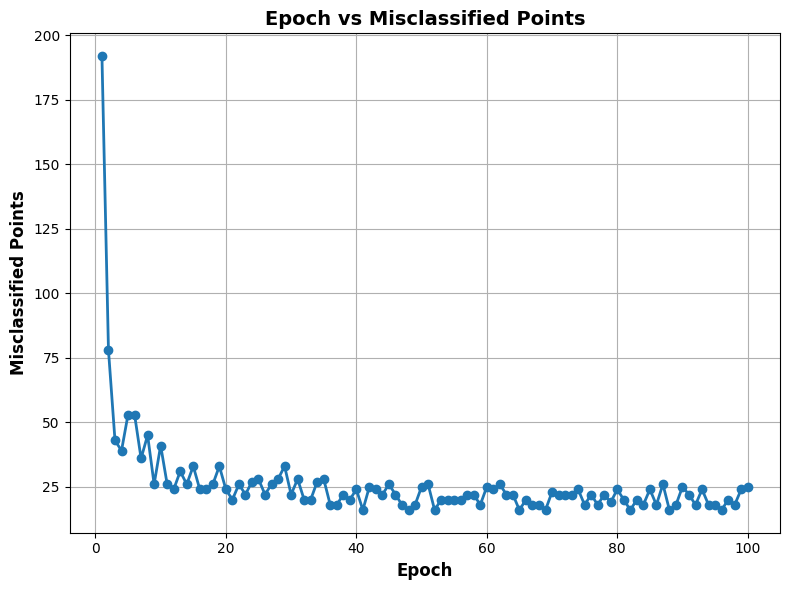

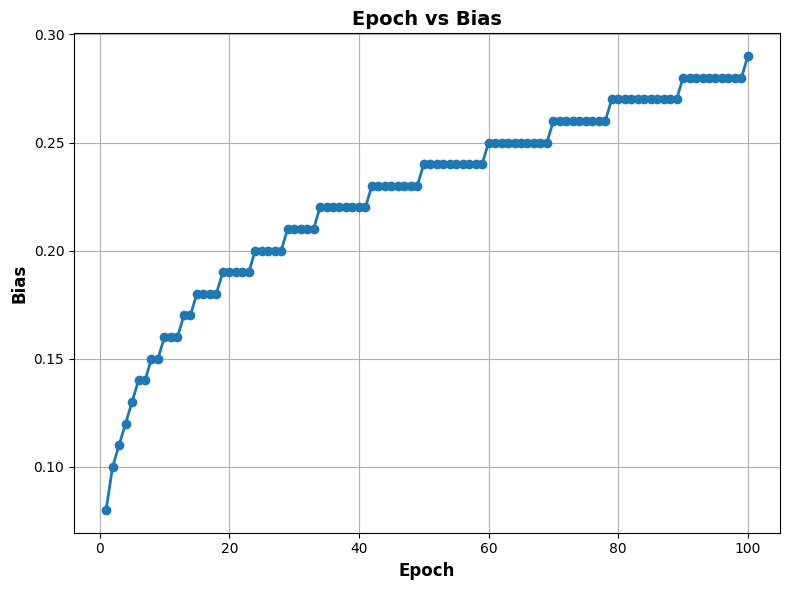

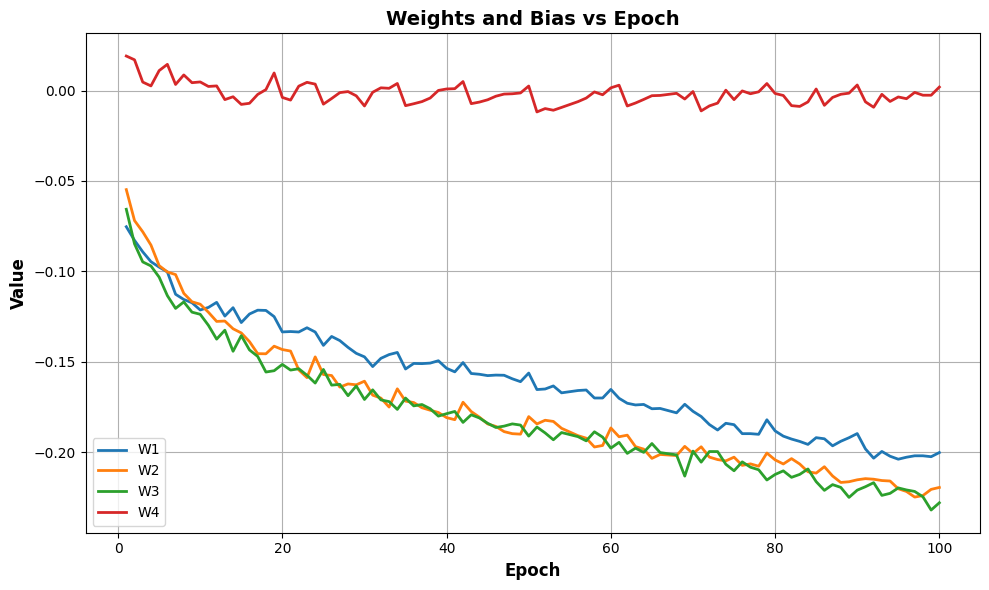

        0.01                    16            
[np.float64(-7.52956133670828), np.float64(-5.477985122377428), np.float64(-6.564071207096558), np.float64(1.9077793045350313)]
Epoch 0
Bias =  8
Number of mis classified points =  192
Weight 1 =  -7.52956133670828 Weight 2 =  -5.477985122377428 Weight 3 =  -6.564071207096558 Weight 4 =  1.9077793045350313

[np.float64(-8.28219899905531), np.float64(-7.188328924178752), np.float64(-8.476376985341998), np.float64(1.6992768849159943)]
Epoch 1
Bias =  10
Number of mis classified points =  78
Weight 1 =  -8.28219899905531 Weight 2 =  -7.188328924178752 Weight 3 =  -8.476376985341998 Weight 4 =  1.6992768849159943

[np.float64(-8.916204436463815), np.float64(-7.8088577233794885), np.float64(-9.473968053405324), np.float64(0.4676220901390017)]
Epoch 2
Bias =  11
Number of mis classified points =  43
Weight 1 =  -8.916204436463815 Weight 2 =  -7.8088577233794885 Weight 3 =  -9.473968053405324 Weight 4 =  0.4676220901390017

[np.float64(-9.4612094

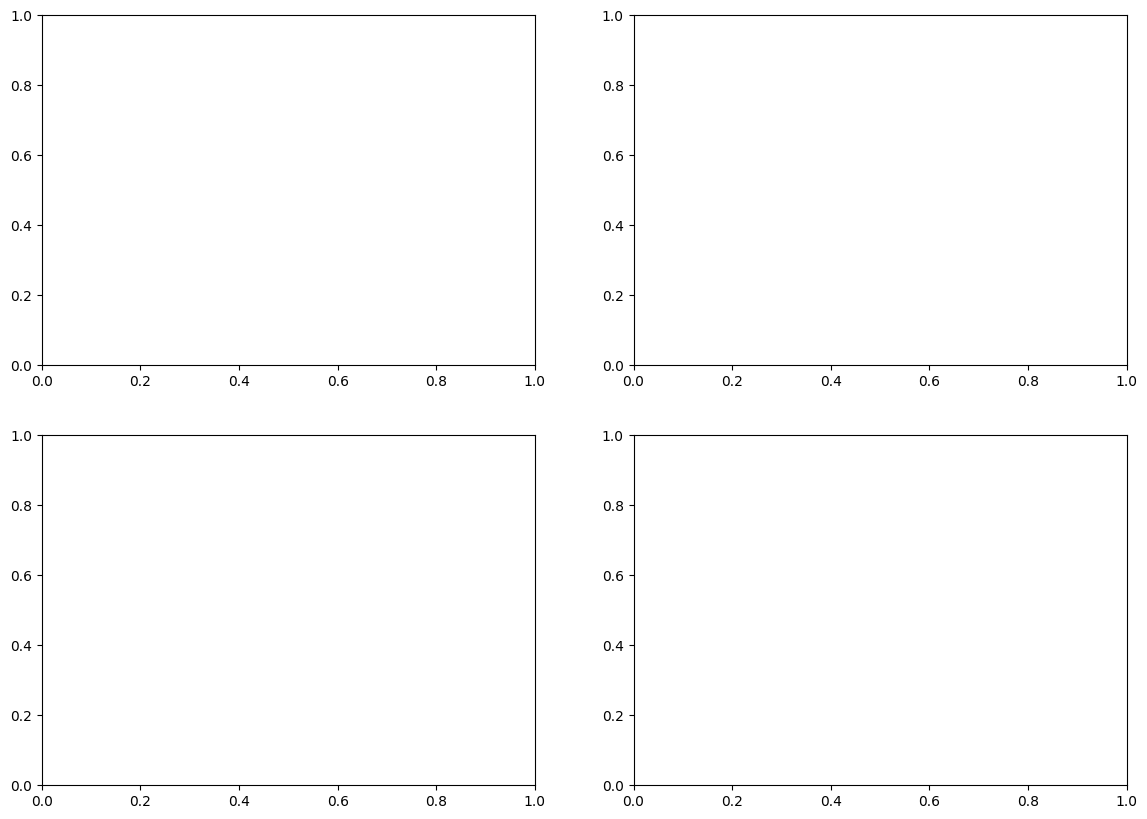

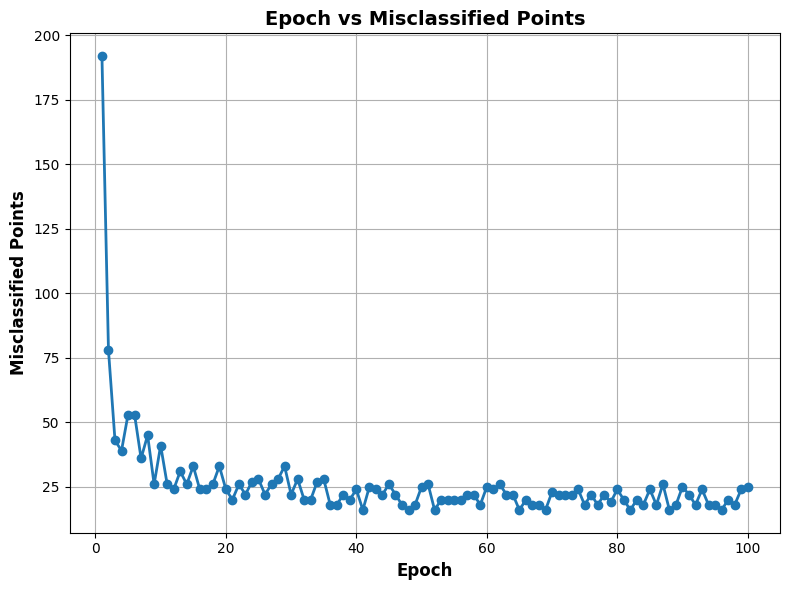

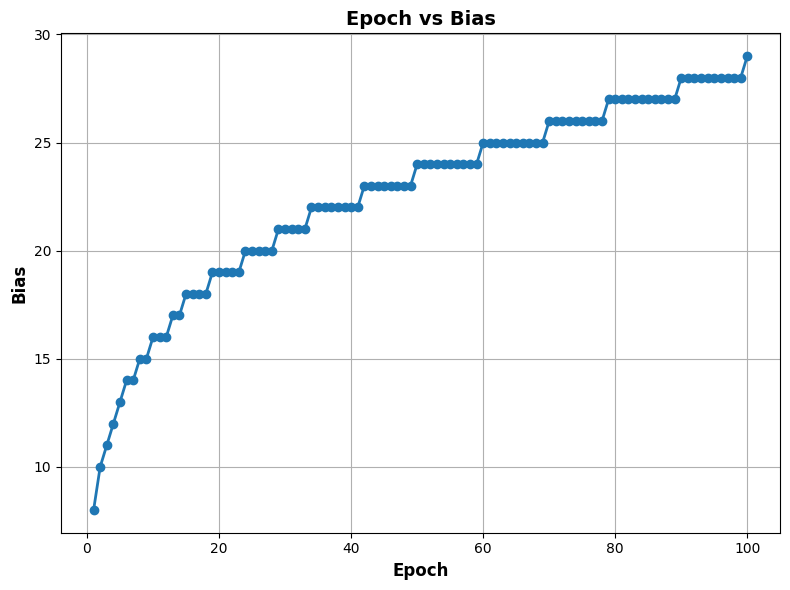

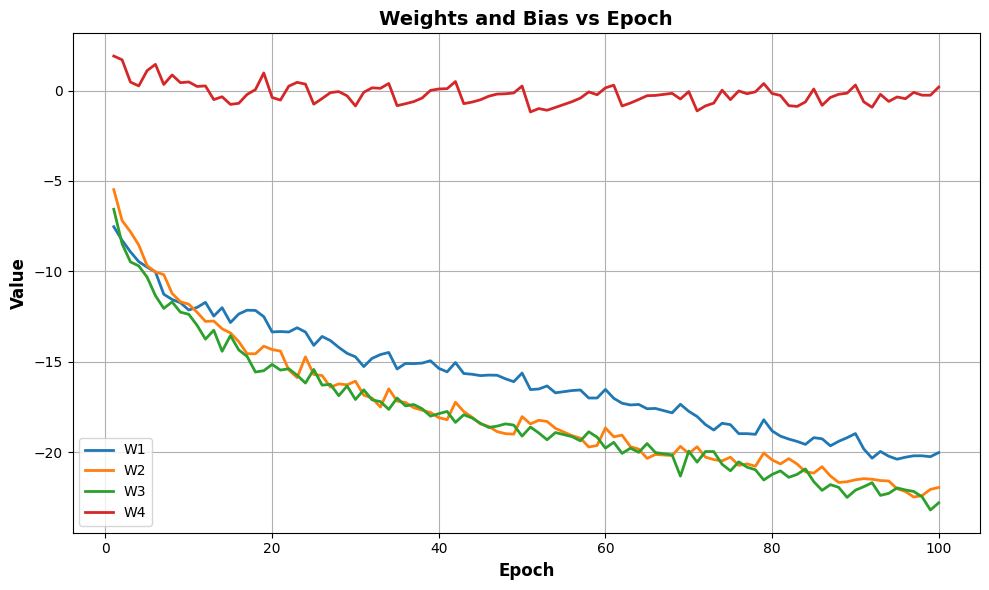

         1                      16            


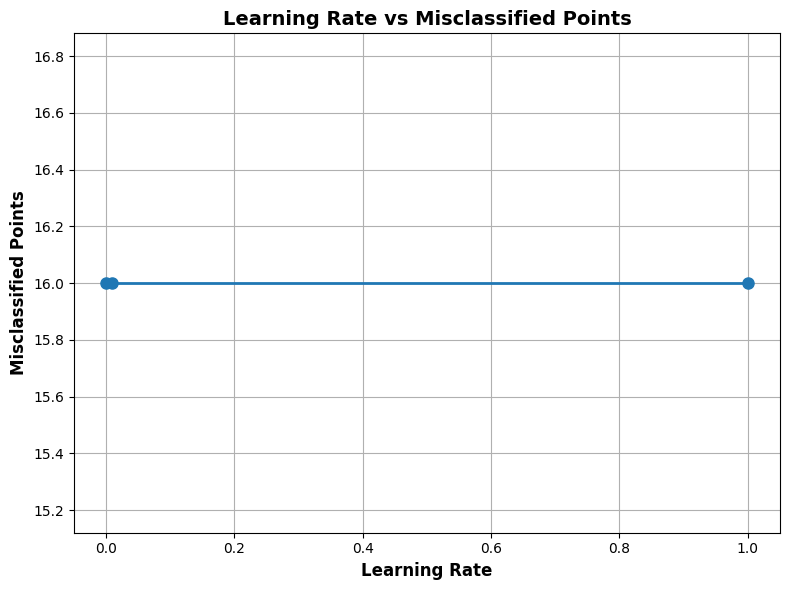

In [77]:
learning_rate, learningrate_compare = learning_diff(
  w1,
    w2,
    w3,
    w4,
    b,
    X_scaled_train,
    y_train,
    epoch
)


   Learning Rate       Misclassified Points   
[np.float64(-0.007529561336708277), np.float64(-0.005477985122377424), np.float64(-0.006564071207096559), np.float64(0.0019077793045350314)]
Epoch 0
Bias =  0.008
Number of mis classified points =  192
Weight 1 =  -0.007529561336708277 Weight 2 =  -0.005477985122377424 Weight 3 =  -0.006564071207096559 Weight 4 =  0.0019077793045350314

[np.float64(-0.0082821989990553), np.float64(-0.007188328924178752), np.float64(-0.008476376985341998), np.float64(0.0016992768849159942)]
Epoch 1
Bias =  0.010000000000000002
Number of mis classified points =  78
Weight 1 =  -0.0082821989990553 Weight 2 =  -0.007188328924178752 Weight 3 =  -0.008476376985341998 Weight 4 =  0.0016992768849159942

[np.float64(-0.0089162044364638), np.float64(-0.007808857723379493), np.float64(-0.009473968053405321), np.float64(0.0004676220901390015)]
Epoch 2
Bias =  0.011000000000000003
Number of mis classified points =  43
Weight 1 =  -0.0089162044364638 Weight 2 =  -0.007

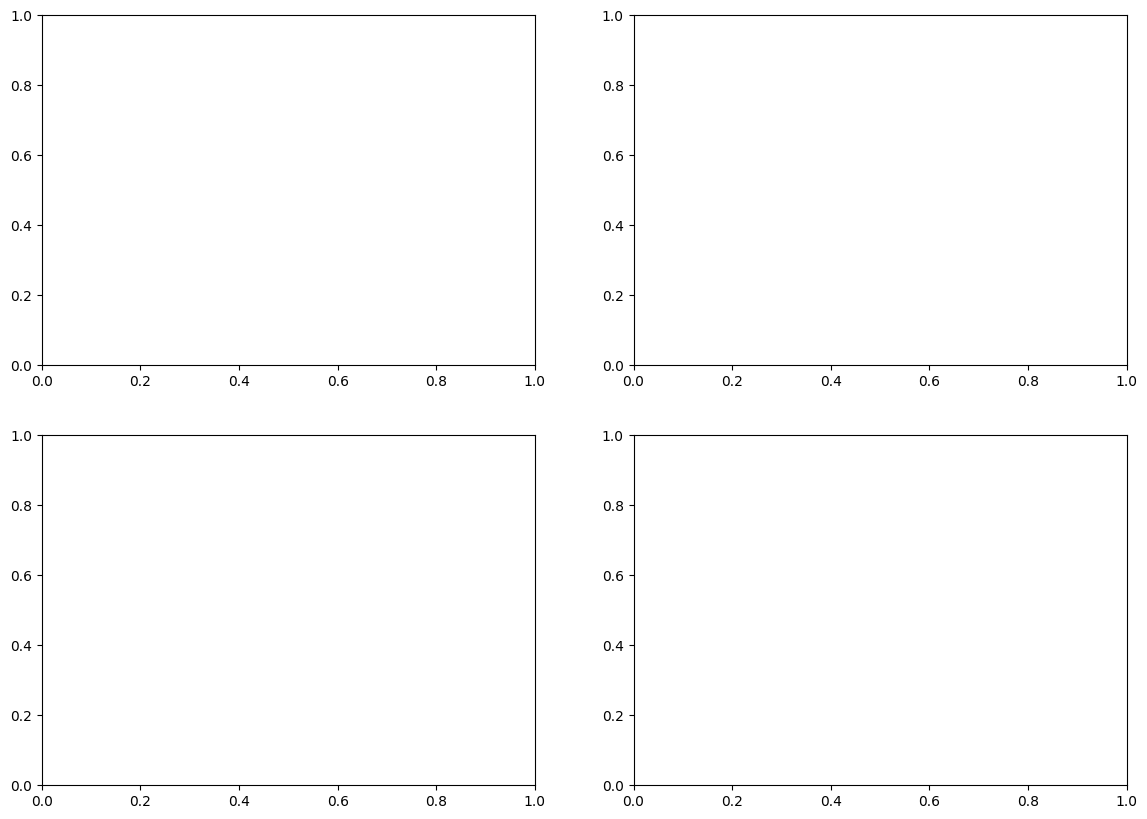

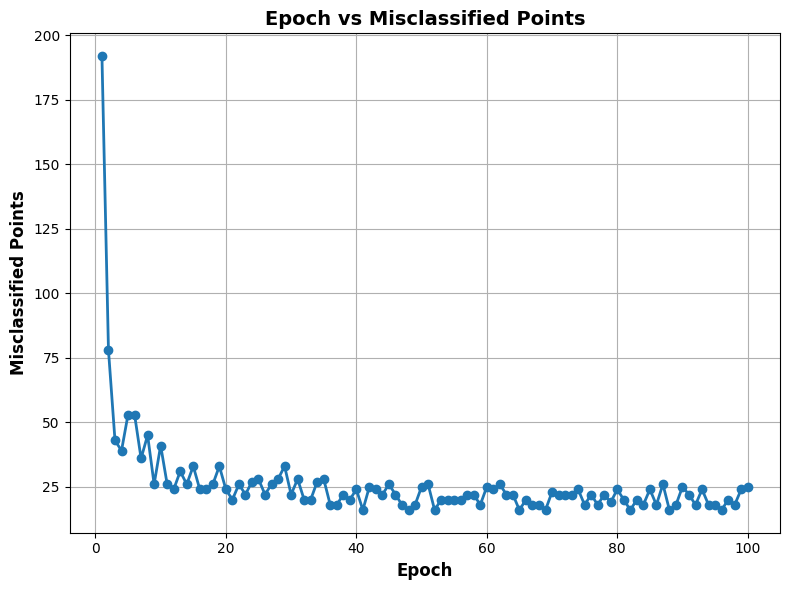

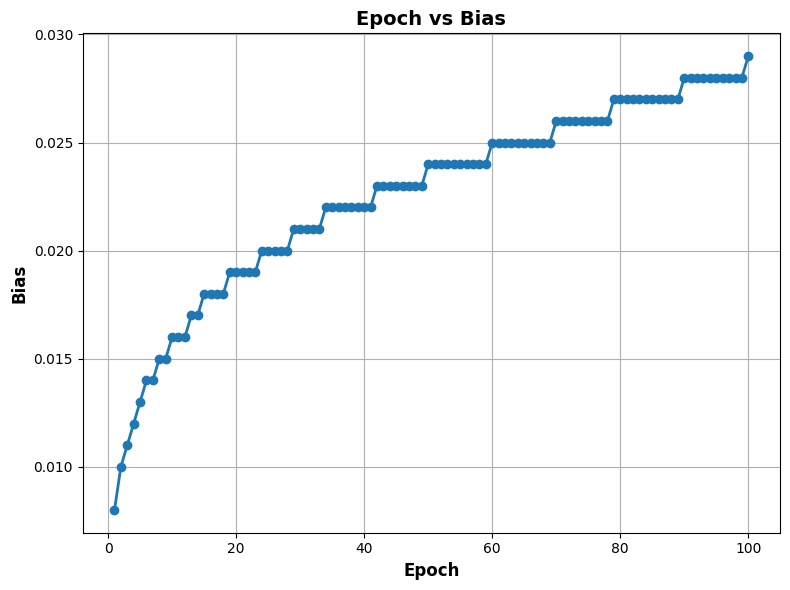

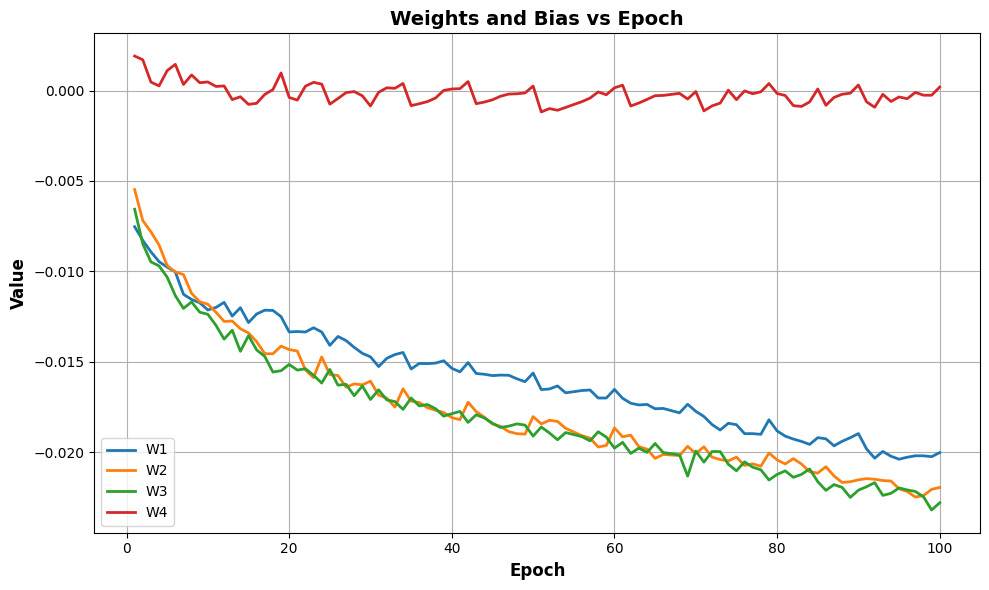

       0.001                    16            
[np.float64(-0.07529561336708274), np.float64(-0.054779851223774254), np.float64(-0.0656407120709656), np.float64(0.0190777930453503)]
Epoch 0
Bias =  0.08
Number of mis classified points =  192
Weight 1 =  -0.07529561336708274 Weight 2 =  -0.054779851223774254 Weight 3 =  -0.0656407120709656 Weight 4 =  0.0190777930453503

[np.float64(-0.08282198999055301), np.float64(-0.07188328924178757), np.float64(-0.08476376985342005), np.float64(0.01699276884915991)]
Epoch 1
Bias =  0.09999999999999999
Number of mis classified points =  78
Weight 1 =  -0.08282198999055301 Weight 2 =  -0.07188328924178757 Weight 3 =  -0.08476376985342005 Weight 4 =  0.01699276884915991

[np.float64(-0.0891620443646381), np.float64(-0.07808857723379496), np.float64(-0.09473968053405335), np.float64(0.004676220901389985)]
Epoch 2
Bias =  0.10999999999999999
Number of mis classified points =  43
Weight 1 =  -0.0891620443646381 Weight 2 =  -0.07808857723379496 Weight 3 =

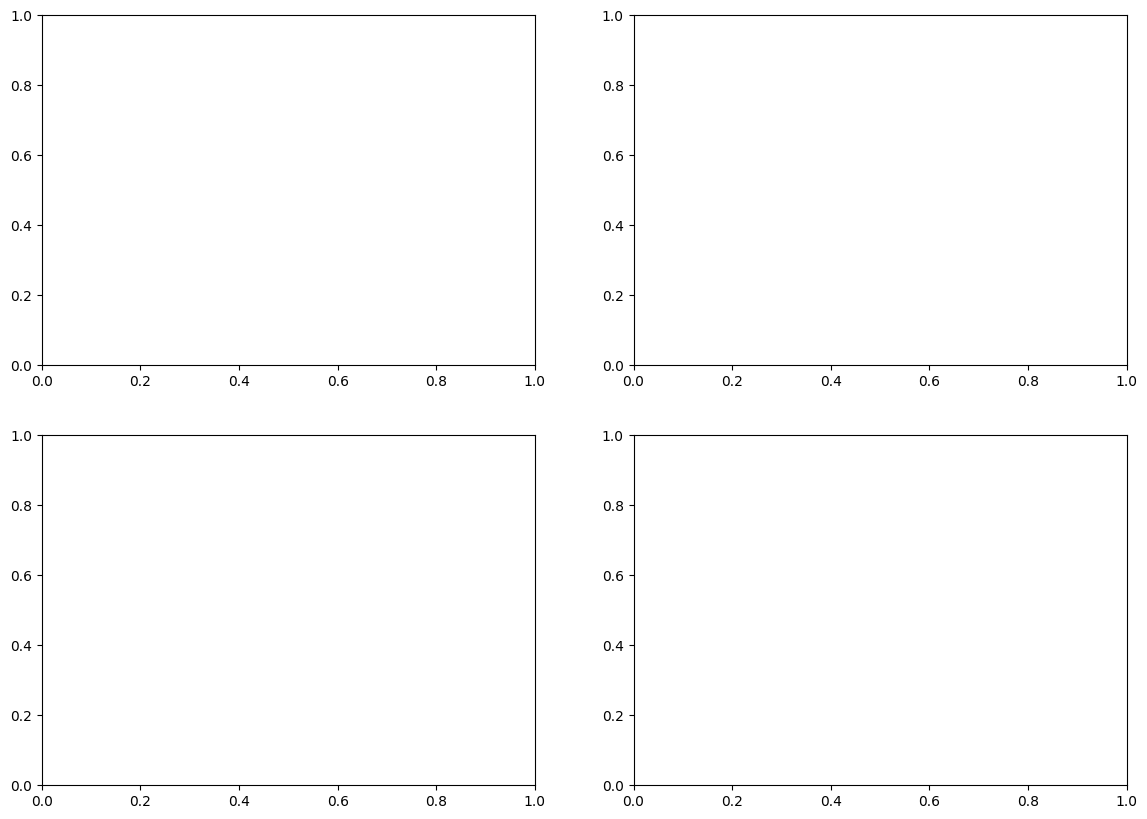

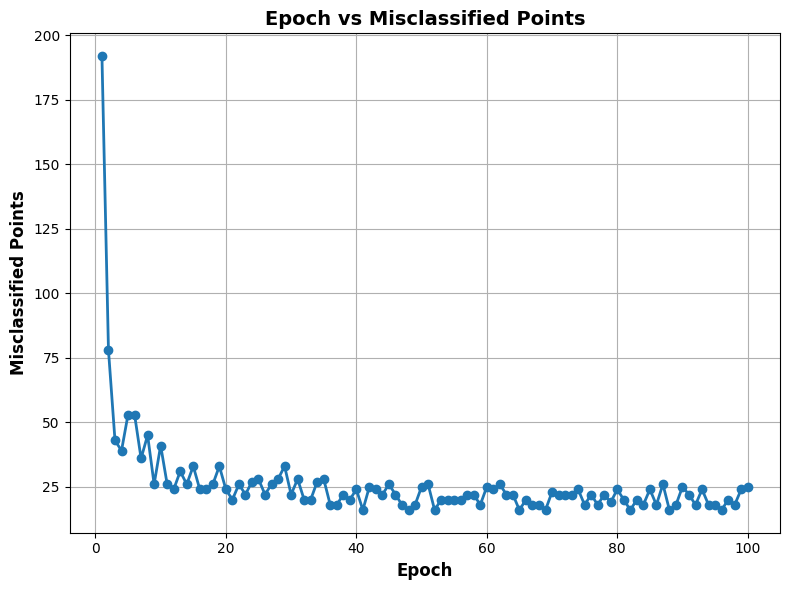

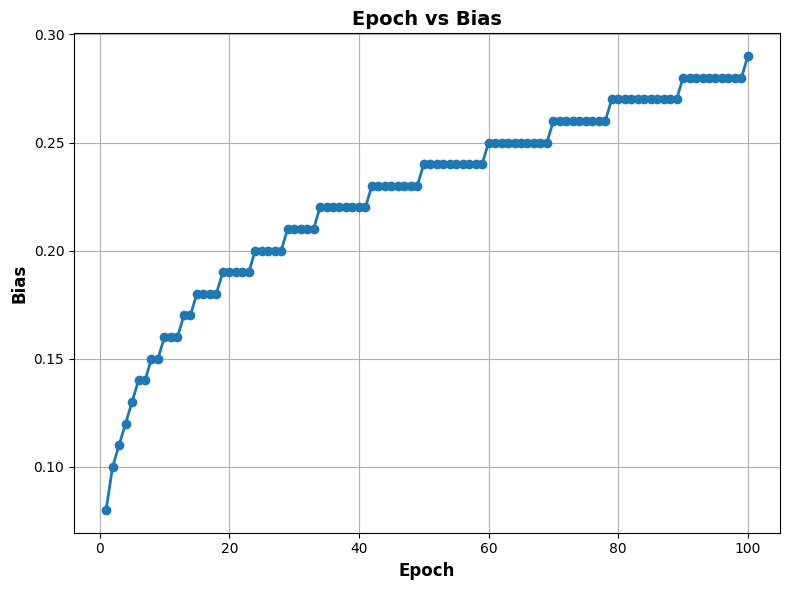

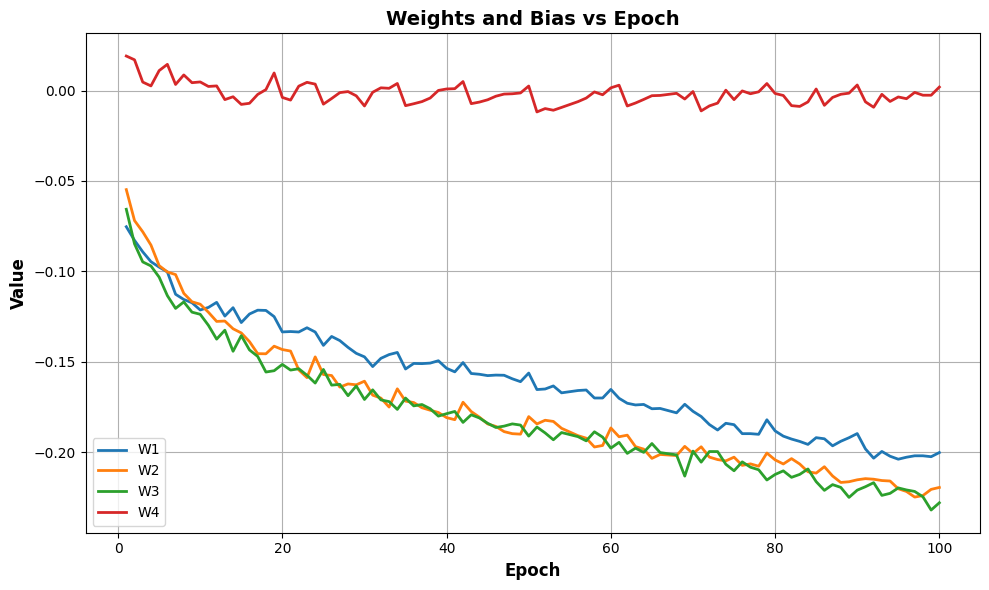

        0.01                    16            
[np.float64(-7.52956133670828), np.float64(-5.477985122377428), np.float64(-6.564071207096558), np.float64(1.9077793045350313)]
Epoch 0
Bias =  8
Number of mis classified points =  192
Weight 1 =  -7.52956133670828 Weight 2 =  -5.477985122377428 Weight 3 =  -6.564071207096558 Weight 4 =  1.9077793045350313

[np.float64(-8.28219899905531), np.float64(-7.188328924178752), np.float64(-8.476376985341998), np.float64(1.6992768849159943)]
Epoch 1
Bias =  10
Number of mis classified points =  78
Weight 1 =  -8.28219899905531 Weight 2 =  -7.188328924178752 Weight 3 =  -8.476376985341998 Weight 4 =  1.6992768849159943

[np.float64(-8.916204436463815), np.float64(-7.8088577233794885), np.float64(-9.473968053405324), np.float64(0.4676220901390017)]
Epoch 2
Bias =  11
Number of mis classified points =  43
Weight 1 =  -8.916204436463815 Weight 2 =  -7.8088577233794885 Weight 3 =  -9.473968053405324 Weight 4 =  0.4676220901390017

[np.float64(-9.4612094

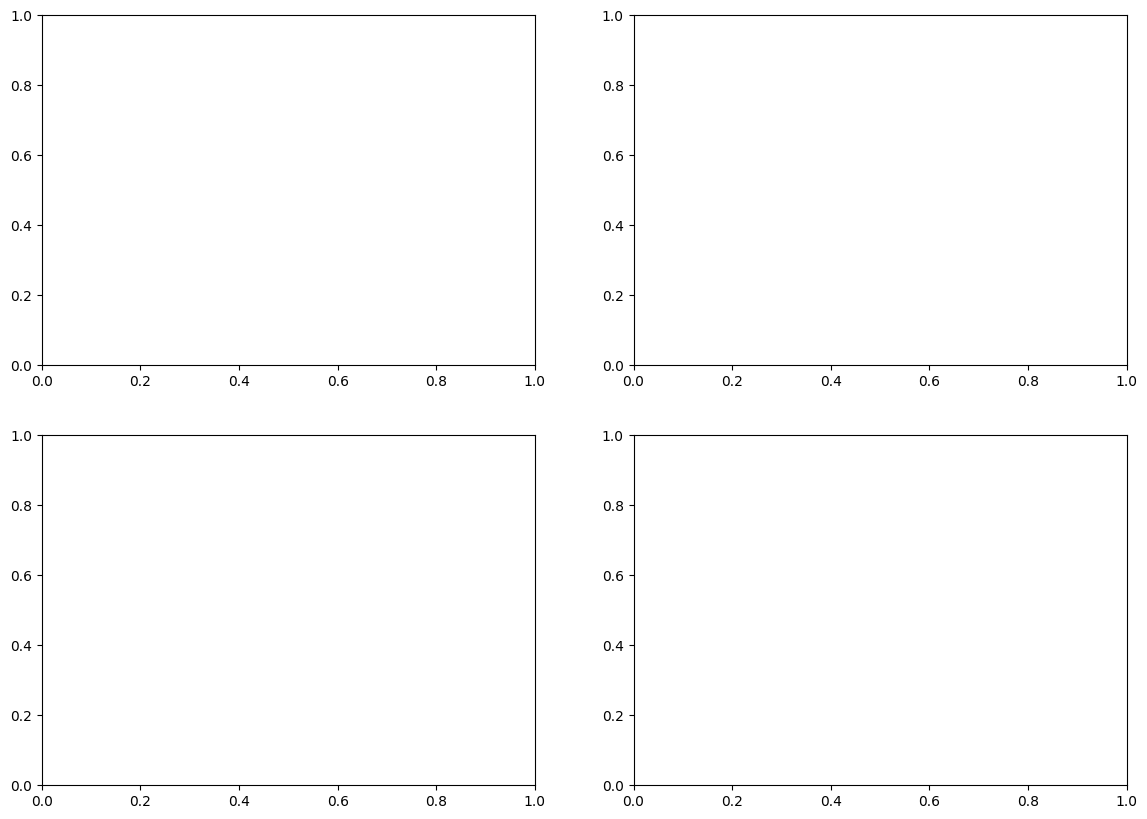

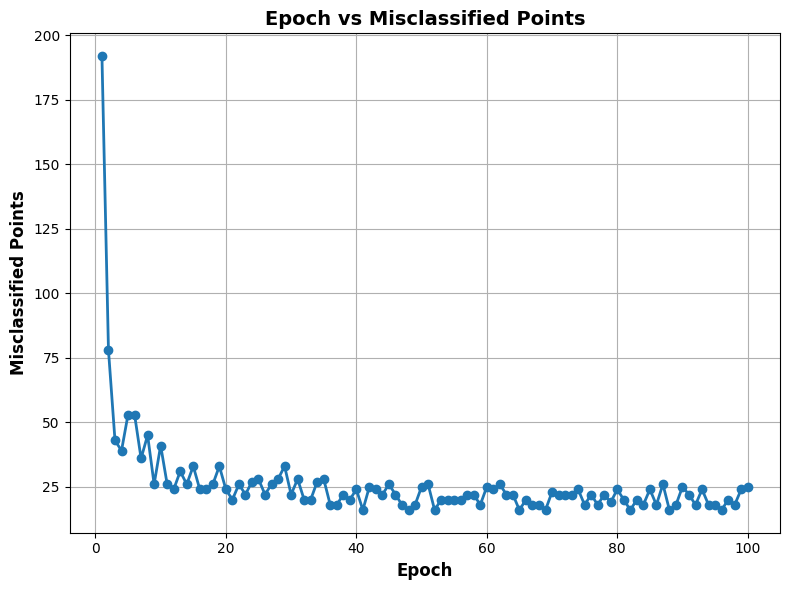

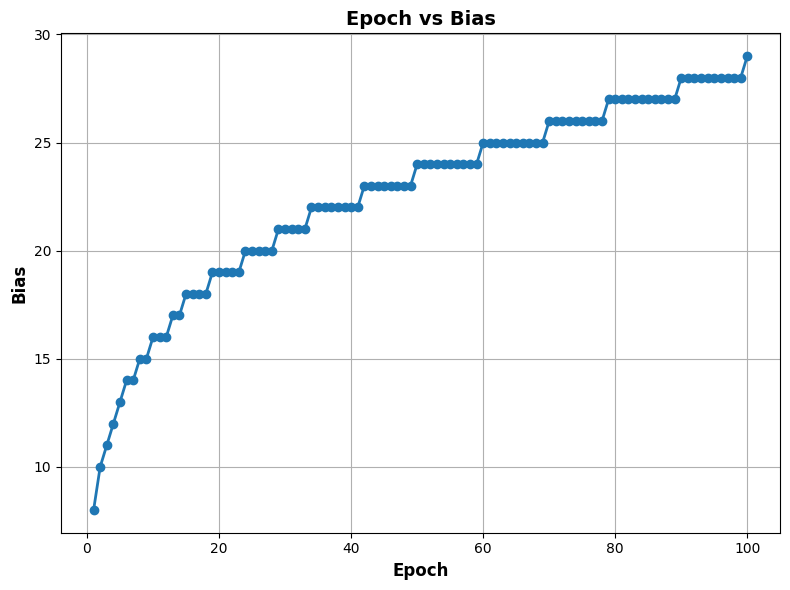

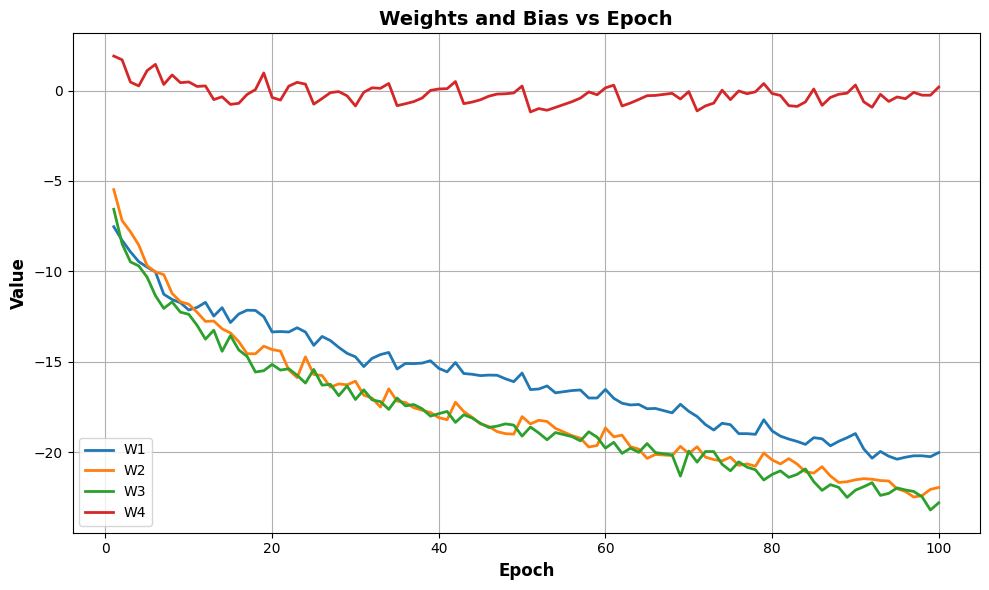

         1                      16            


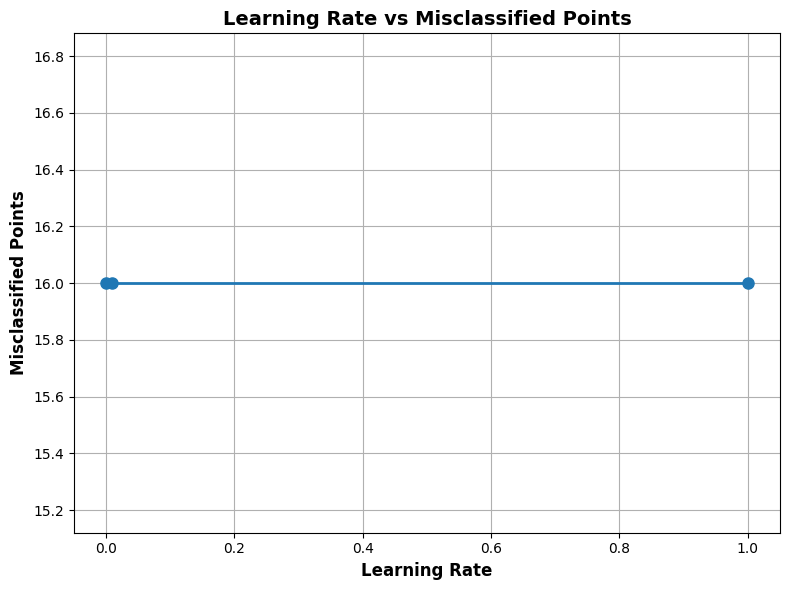

In [78]:
learning_rate, learningrate_compare = learning_diff(w1,w2,w3,w4,b,X_scaled_train,y_train,epoch)

In [79]:
ans = learningrate_compare[1]

In [80]:
we1 = ans[0][0]
we2 = ans[0][1]
we3 = ans[0][2]
we4 = ans[0][3]
bf = ans[0][4]
def test_percep(x1,x2,x3,x4,we1,we2,we3,we4,bf):
  z = x1*we1 + x2*we2 + x3*we3 + x4*we4 + bf
  return activation(z)


In [81]:
y_pred = []
for i in range(len(X_scaled_test)):
    x1 = X_scaled_test[i][0]
    x2 = X_scaled_test[i][1]
    x3 = X_scaled_test[i][2]
    x4 = X_scaled_test[i][3]
    yy = test_percep(x1,x2,x3,x4,we1,we2,we3,we4,bf)
    y_pred.append(yy)


In [82]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

In [83]:
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("\nConfusion Matrix")
print(cm)

Accuracy : 0.9890909090909091
Precision: 0.9917355371900827
Recall   : 0.9836065573770492
F1 Score : 0.9876543209876543

Confusion Matrix
[[152   1]
 [  2 120]]


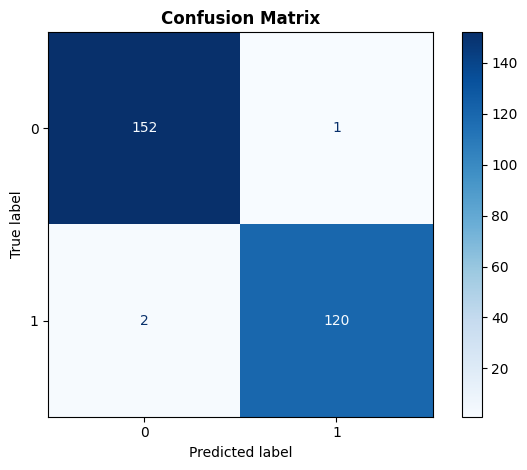

In [84]:
#Plotting the Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig("Confusion_Matrix.eps",dpi=600,format='eps',bbox_inches='tight')
plt.show()

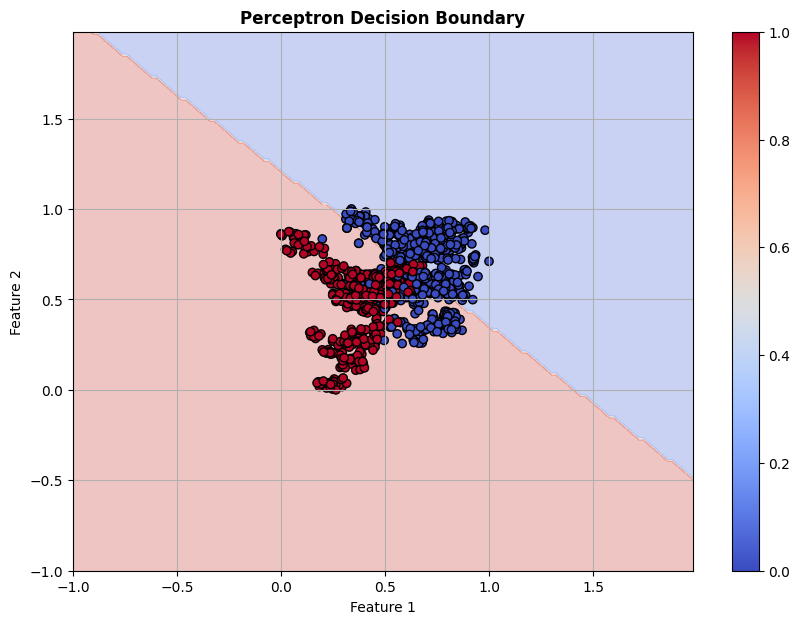

In [88]:
x_min, x_max = X_scaled_train[:,0].min() - 1, X_scaled_train[:,0].max() + 1
y_min, y_max = X_scaled_train[:,1].min() - 1, X_scaled_train[:,1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),np.arange(y_min, y_max, 0.02))
Z = []
for i in range(xx.shape[0]):
    row = []
    for j in range(xx.shape[1]):
        x1 = xx[i,j]
        x2 = yy[i,j]
        x3 = 0
        x4 = 0
        pred = test_percep(x1,x2,x3,x4,we1,we2,we3,we4,bf)
        row.append(pred)
    Z.append(row)
Z = np.array(Z)

plt.figure(figsize=(10,7))

plt.contourf(xx,yy,Z,alpha=0.3,cmap='coolwarm')
scatter = plt.scatter(X_scaled_train[:,0],X_scaled_train[:,1],c=y_train,cmap='coolwarm',edgecolors='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Perceptron Decision Boundary',fontweight='bold')
plt.colorbar(scatter)
plt.grid(True)
plt.savefig("Decision_boundary.eps",dpi=600,format='eps',bbox_inches='tight')
plt.show()